# 03 — Physical Scaling

**Benchmark:** Benchmark 2 — Physical Scaling by Dataset Size  
**Scope:** Synthetic size benchmark, từ `5GB` đến `20GB` trong dữ liệu hiện có.  
**Frameworks:** Pandas, Polars eager, Polars lazy, Dask.

Notebook này không chạy benchmark workload. Notebook chỉ đọc kết quả đã có trong `results/raw/` và dùng chúng để giải thích physical scaling: runtime, peak memory, memory efficiency, stability, trade-off và failure behavior.

## 1. Research Questions

Notebook này đánh giá khả năng mở rộng theo kích thước vật lý của dataset synthetic qua năm câu hỏi:

1. Runtime thay đổi như thế nào khi input tăng từ `5GB` lên `20GB`?
2. Peak memory thay đổi ra sao so với kích thước input?
3. Framework nào giữ được performance ổn định hơn ở size lớn?
4. Có bằng chứng nào về failure hoặc instability gần ranh giới bộ nhớ của máy không?
5. Có khoảng thời gian đáng kể nào nằm ngoài `time_s` giữa các run liên tiếp trong cùng `framework` và `dataset_size` không?

Các biểu đồ và bảng sau đó đều phục vụ các câu hỏi này. Vì dữ liệu hiện có chỉ gồm `5GB`, `10GB`, và `20GB`, mọi kết luận chỉ nên đọc trong phạm vi size này.

## 2. Setup and Data Loading

Code dùng key và tên biến tiếng Anh để khớp với CSV benchmark. Nội dung markdown dùng tiếng Việt để giải thích kết quả.

In [68]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() in {"benchmark", "benchmarks", "analysis", "report", "data_prep"}:
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

RESULTS_DIR = PROJECT_ROOT / "results" / "raw"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "notebook_03_physical_scaling"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RESULT_FILES = [
    RESULTS_DIR / "pandas_size_results.csv",
    RESULTS_DIR / "polars_size_results.csv",
    RESULTS_DIR / "polars_eager_size_results.csv",
    RESULTS_DIR / "dask_size_results.csv",
]

SIZE_ORDER = ["1GB", "5GB", "10GB", "20GB", ">RAM"]
MAIN_WORKLOADS = ["filter", "groupby"]
STRESS_WORKLOADS = ["join", "pipeline"]
WORKLOAD_ORDER = MAIN_WORKLOADS + STRESS_WORKLOADS
FRAMEWORK_ORDER = ["pandas", "polars_lazy", "polars_eager", "dask"]

print(f"Project root : {PROJECT_ROOT}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Figure dir   : {FIGURE_DIR}")

Project root : D:\Polar vs Dask
Results dir  : D:\Polar vs Dask\results\raw
Figure dir   : D:\Polar vs Dask\results\figures\notebook_03_physical_scaling


In [69]:
available_files = [path for path in RESULT_FILES if path.exists()]
missing_files = [path.name for path in RESULT_FILES if not path.exists()]

if missing_files:
    print("Missing files:", missing_files)

if not available_files:
    raise FileNotFoundError("No size benchmark CSV files were found in results/raw/.")

frames = []
for path in available_files:
    frame = pd.read_csv(path)
    frame["source_file"] = path.name
    frames.append(frame)

df_raw = pd.concat(frames, ignore_index=True)

required_columns = {
    "timestamp", "framework", "workload", "dataset_size", "n_rows",
    "run_index", "time_s", "peak_memory_mb", "throughput_rows_per_s", "status", "notes"
}
missing_columns = sorted(required_columns - set(df_raw.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

numeric_columns = ["n_rows", "run_index", "time_s", "peak_memory_mb", "throughput_rows_per_s"]
for column in numeric_columns:
    df_raw[column] = pd.to_numeric(df_raw[column], errors="coerce")

def parse_size_gb(value):
    text = str(value).upper().strip()
    if text.endswith("GB"):
        return float(text.replace("GB", ""))
    return np.nan

def validate_known_values(df, column, allowed_values):
    actual = set(df[column].dropna().astype(str).unique())
    allowed = set(allowed_values)
    unknown = sorted(actual - allowed)

    if unknown:
        raise ValueError(
            f"Unknown values in {column}: {unknown}. "
            f"Update the ordering list if these are valid."
        )

validate_known_values(df_raw, "framework", FRAMEWORK_ORDER)
validate_known_values(df_raw, "workload", WORKLOAD_ORDER)
validate_known_values(df_raw, "dataset_size", SIZE_ORDER)

df_raw["status"] = df_raw["status"].fillna("unknown").str.lower()
df_raw["notes"] = df_raw["notes"].fillna("")
df_raw["dataset_size_gb"] = df_raw["dataset_size"].map(parse_size_gb)
df_raw["framework"] = pd.Categorical(df_raw["framework"], categories=FRAMEWORK_ORDER, ordered=True)
df_raw["workload"] = pd.Categorical(df_raw["workload"], categories=WORKLOAD_ORDER, ordered=True)
df_raw["dataset_size"] = pd.Categorical(df_raw["dataset_size"], categories=SIZE_ORDER, ordered=True)

df_raw = df_raw.sort_values(["dataset_size", "workload", "framework", "run_index"]).reset_index(drop=True)

display(df_raw.head())
print(f"Rows loaded     : {len(df_raw):,}")
print(f"Available sizes : {list(df_raw['dataset_size'].dropna().astype(str).unique())}")
print(f"Available files : {[path.name for path in available_files]}")

,timestamp,framework,workload,dataset_size,n_rows,run_index,time_s,peak_memory_mb,throughput_rows_per_s,status,notes,source_file,dataset_size_gb
0,2026-05-08T22:21:56,pandas,filter,5GB,6917051,1,13.6951,4885.55,505074,ok,,pandas_size_results.csv,5.0
1,2026-05-08T22:22:10,pandas,filter,5GB,6917051,2,13.6911,4874.48,505222,ok,,pandas_size_results.csv,5.0
2,2026-05-08T22:22:23,pandas,filter,5GB,6917051,3,13.7053,4816.89,504698,ok,,pandas_size_results.csv,5.0
3,2026-05-08T21:41:14,polars_lazy,filter,5GB,6917051,1,2.9468,2858.27,2347341,ok,,polars_size_results.csv,5.0
4,2026-05-08T21:41:17,polars_lazy,filter,5GB,6917051,2,2.9455,2801.55,2348334,ok,,polars_size_results.csv,5.0


Rows loaded     : 144
Available sizes : ['5GB', '10GB', '20GB']
Available files : ['pandas_size_results.csv', 'polars_size_results.csv', 'polars_eager_size_results.csv', 'dask_size_results.csv']


## 3. Data Completeness Check

Trước khi diễn giải performance, cần kiểm tra số lần chạy thành công cho từng tổ hợp framework, workload và size. Phân tích runtime/memory chỉ dùng `status == "ok"`; failure được giữ riêng ở cuối notebook.

In [70]:
df_ok = df_raw[df_raw["status"] == "ok"].copy()
df_fail = df_raw[df_raw["status"] != "ok"].copy()

run_count = (
    df_raw
    .groupby(["framework", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_runs")
    .reset_index()
)

display(run_count)
print(f"Successful rows: {len(df_ok):,}")
print(f"Failed rows    : {len(df_fail):,}")

,framework,workload,dataset_size,status,n_runs
0,pandas,filter,5GB,ok,3
1,pandas,filter,10GB,ok,3
2,pandas,filter,20GB,ok,3
3,pandas,groupby,5GB,ok,3
4,pandas,groupby,10GB,ok,3
5,pandas,groupby,20GB,ok,3
6,pandas,join,5GB,ok,3
7,pandas,join,10GB,ok,3
8,pandas,join,20GB,ok,3
9,pandas,pipeline,5GB,ok,3


Successful rows: 144
Failed rows    : 0


In [71]:
completion_matrix = (
    df_ok
    .groupby(["framework", "workload", "dataset_size"], observed=True)["run_index"]
    .count()
    .rename("successful_runs")
    .reset_index()
    .pivot_table(
        index=["framework", "workload"],
        columns="dataset_size",
        values="successful_runs",
        fill_value=0,
        observed=True,
    )
)

display(completion_matrix)

incomplete_cells = completion_matrix.stack()[completion_matrix.stack() < 3]
if len(incomplete_cells):
    print("Cells with fewer than 3 successful runs:")
    display(incomplete_cells.rename("successful_runs").reset_index())
else:
    print("All available framework/workload/size cells have 3 successful runs.")

dataset_size           5GB  10GB  20GB
framework    workload                 
pandas       filter    3.0   3.0   3.0
             groupby   3.0   3.0   3.0
             join      3.0   3.0   3.0
             pipeline  3.0   3.0   3.0
polars_lazy  filter    3.0   3.0   3.0
             groupby   3.0   3.0   3.0
             join      3.0   3.0   3.0
             pipeline  3.0   3.0   3.0
polars_eager filter    3.0   3.0   3.0
             groupby   3.0   3.0   3.0
             join      3.0   3.0   3.0
             pipeline  3.0   3.0   3.0
dask         filter    3.0   3.0   3.0
             groupby   3.0   3.0   3.0
             join      3.0   3.0   3.0
             pipeline  3.0   3.0   3.0

All available framework/workload/size cells have 3 successful runs.


### What this means

Dữ liệu hiện có đủ để so sánh cơ bản vì mỗi tổ hợp đang có 3 successful runs. Điều này cho phép tính mean và standard deviation thay vì chỉ dựa vào một lần chạy đơn lẻ.

Tuy nhiên, 3 runs vẫn là số mẫu nhỏ. Vì vậy các kết luận về ranking nên đọc cùng variance, đặc biệt với workload có runtime dao động mạnh hoặc chịu ảnh hưởng của cache, scheduler, pagefile và background process.

## 4. Summary Table

Bảng `summary` là nguồn chính cho các phân tích tiếp theo. Ngoài mean/std, bảng này thêm các metric chuẩn hóa theo input size và variance.

In [72]:
summary = (
    df_ok
    .groupby(["framework", "workload", "dataset_size"], observed=True)
    .agg(
        mean_time_s=("time_s", "mean"),
        std_time_s=("time_s", "std"),
        mean_peak_memory_mb=("peak_memory_mb", "mean"),
        std_peak_memory_mb=("peak_memory_mb", "std"),
        mean_throughput_rows_per_s=("throughput_rows_per_s", "mean"),
        std_throughput_rows_per_s=("throughput_rows_per_s", "std"),
        mean_n_rows=("n_rows", "mean"),
        dataset_size_gb=("dataset_size_gb", "mean"),
        n_runs=("run_index", "count"),
    )
    .reset_index()
)

summary["mean_peak_memory_gb"] = summary["mean_peak_memory_mb"] / 1024
summary["std_peak_memory_gb"] = summary["std_peak_memory_mb"] / 1024
summary["mean_throughput_mrows_per_s"] = summary["mean_throughput_rows_per_s"] / 1_000_000
summary["memory_per_input_gb"] = np.where(
    summary["dataset_size_gb"] > 0,
    summary["mean_peak_memory_gb"] / summary["dataset_size_gb"],
    np.nan,
)

summary["runtime_cv"] = np.where(
    summary["mean_time_s"] > 0,
    summary["std_time_s"] / summary["mean_time_s"],
    np.nan,
)

summary["memory_cv"] = np.where(
    summary["mean_peak_memory_gb"] > 0,
    summary["std_peak_memory_gb"] / summary["mean_peak_memory_gb"],
    np.nan,
)

summary = summary.sort_values(["dataset_size", "workload", "framework"]).reset_index(drop=True)
agg = summary  # Backward-compatible alias for older cells or ad-hoc exploration.

display(summary.round(4))

,framework,workload,dataset_size,mean_time_s,std_time_s,mean_peak_memory_mb,std_peak_memory_mb,mean_throughput_rows_per_s,std_throughput_rows_per_s,mean_n_rows,dataset_size_gb,n_runs,mean_peak_memory_gb,std_peak_memory_gb,mean_throughput_mrows_per_s,memory_per_input_gb,runtime_cv,memory_cv
0,pandas,filter,5GB,13.6972,0.0073,4858.9733,36.8631,5.049980e+05,270.1407,6917051.0,5.0,3,4.7451,0.0360,0.5050,0.9490,0.0005,0.0076
1,polars_lazy,filter,5GB,2.6350,0.5390,2799.2533,60.1979,2.710825e+06,628713.5659,6917051.0,5.0,3,2.7336,0.0588,2.7108,0.5467,0.2046,0.0215
2,polars_eager,filter,5GB,1.1533,0.0532,3287.2600,63.8303,6.006113e+06,272626.6782,6917051.0,5.0,3,3.2102,0.0623,6.0061,0.6420,0.0461,0.0194
3,dask,filter,5GB,2.2590,0.0148,4801.8167,78.4008,3.062174e+06,20013.6235,6917051.0,5.0,3,4.6893,0.0766,3.0622,0.9379,0.0066,0.0163
4,pandas,groupby,5GB,15.0171,0.0825,4738.7367,18.1100,4.606223e+05,2525.1151,6917051.0,5.0,3,4.6277,0.0177,0.4606,0.9255,0.0055,0.0038
5,polars_lazy,groupby,5GB,2.0560,0.0383,2639.4867,185.3628,3.365096e+06,62089.0092,6917051.0,5.0,3,2.5776,0.1810,3.3651,0.5155,0.0186,0.0702
6,polars_eager,groupby,5GB,1.7393,0.0125,3747.1833,50.5304,3.977081e+06,28594.2157,6917051.0,5.0,3,3.6594,0.0493,3.9771,0.7319,0.0072,0.0135
7,dask,groupby,5GB,1.0651,0.0134,2362.8300,19.5301,6.495158e+06,81225.8727,6917051.0,5.0,3,2.3075,0.0191,6.4952,0.4615,0.0126,0.0083
8,pandas,join,5GB,23.2944,0.1594,6428.6767,106.0328,2.969493e+05,2026.7314,6917051.0,5.0,3,6.2780,0.1035,0.2969,1.2556,0.0068,0.0165
9,polars_lazy,join,5GB,6.3021,0.0375,4691.2967,37.2898,1.097610e+06,6550.9486,6917051.0,5.0,3,4.5813,0.0364,1.0976,0.9163,0.0059,0.0079


## 5. Inter-run Gap Analysis

Phần này kiểm tra khoảng thời gian giữa các run liên tiếp trong cùng một nhóm `framework` và `dataset_size`.

Trong raw benchmark log, cột `timestamp` thể hiện thời điểm bắt đầu của mỗi run, còn `time_s` là runtime được đo trực tiếp bên trong benchmark. Vì log hiện tại không có `end_time`, notebook ước lượng thời điểm kết thúc của một run bằng:

`estimated_end_time = timestamp + time_s`

Sau đó, khoảng trống trước run tiếp theo được tính bằng:

`gap_to_next_run_s = next_timestamp - estimated_end_time`

Giá trị này phản ánh phần thời gian nằm ngoài `time_s` giữa hai run liên tiếp. Khoảng thời gian đó có thể đến từ setup, cleanup, I/O, logging, scheduler overhead, garbage collection hoặc chuẩn bị workload tiếp theo.

Caution: đây không phải I/O profiling đầy đủ. Vì benchmark chưa đo riêng `read_time_s`, `write_time_s`, `setup_time_s`, `cleanup_time_s` và `compute_time_s`, gap chỉ nên được xem là **inter-run overhead** hoặc **unmeasured overhead**, không nên kết luận trực tiếp rằng toàn bộ gap là I/O.

In [73]:
timing_df = df_raw.copy()
timing_df["timestamp_dt"] = pd.to_datetime(timing_df["timestamp"], errors="coerce")
timing_df["estimated_end_time"] = timing_df["timestamp_dt"] + pd.to_timedelta(timing_df["time_s"], unit="s")

timing_df = timing_df.sort_values(["framework", "dataset_size", "timestamp_dt", "run_index"]).reset_index(drop=True)

group_keys = ["framework", "dataset_size"]
timing_df["next_timestamp"] = timing_df.groupby(group_keys, observed=True)["timestamp_dt"].shift(-1)
timing_df["next_workload"] = timing_df.groupby(group_keys, observed=True)["workload"].shift(-1)
timing_df["next_run_index"] = timing_df.groupby(group_keys, observed=True)["run_index"].shift(-1)
timing_df["gap_to_next_run_s"] = (timing_df["next_timestamp"] - timing_df["estimated_end_time"]).dt.total_seconds()

inter_run_gap = (
    timing_df
    .dropna(subset=["timestamp_dt", "next_timestamp", "gap_to_next_run_s"])
    .copy()
)

# Negative values usually indicate timestamp resolution/rounding issues or overlapping logging.
inter_run_gap["gap_to_next_run_s"] = inter_run_gap["gap_to_next_run_s"].clip(lower=0)

display(
    inter_run_gap[[
        "framework", "dataset_size", "workload", "run_index", "time_s",
        "timestamp_dt", "estimated_end_time", "next_workload", "next_run_index",
        "next_timestamp", "gap_to_next_run_s",
    ]].sort_values(["framework", "dataset_size", "timestamp_dt"]).round(4)
)

,framework,dataset_size,workload,run_index,time_s,timestamp_dt,estimated_end_time,next_workload,next_run_index,next_timestamp,gap_to_next_run_s
0,pandas,5GB,filter,1,13.6951,2026-05-08 22:21:56,2026-05-08 22:22:09.695100,filter,2.0,2026-05-08 22:22:10,0.3049
1,pandas,5GB,filter,2,13.6911,2026-05-08 22:22:10,2026-05-08 22:22:23.691100,filter,3.0,2026-05-08 22:22:23,0.0000
2,pandas,5GB,filter,3,13.7053,2026-05-08 22:22:23,2026-05-08 22:22:36.705300,groupby,1.0,2026-05-08 22:22:53,16.2947
3,pandas,5GB,groupby,1,14.9986,2026-05-08 22:22:53,2026-05-08 22:23:07.998600,groupby,2.0,2026-05-08 22:23:08,0.0014
4,pandas,5GB,groupby,2,15.1072,2026-05-08 22:23:08,2026-05-08 22:23:23.107200,groupby,3.0,2026-05-08 22:23:23,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
138,dask,20GB,join,1,122.6979,2026-05-08 22:08:10,2026-05-08 22:10:12.697900,join,2.0,2026-05-08 22:10:13,0.3021
139,dask,20GB,join,2,122.3509,2026-05-08 22:10:13,2026-05-08 22:12:15.350900,join,3.0,2026-05-08 22:12:11,0.0000
140,dask,20GB,join,3,117.6643,2026-05-08 22:12:11,2026-05-08 22:14:08.664300,pipeline,1.0,2026-05-08 22:13:02,0.0000
141,dask,20GB,pipeline,1,24.8872,2026-05-08 22:13:02,2026-05-08 22:13:26.887200,pipeline,2.0,2026-05-08 22:13:26,0.0000


In [74]:
gap_summary = (
    inter_run_gap
    .groupby(["framework", "dataset_size"], observed=True)
    .agg(
        n_gaps=("gap_to_next_run_s", "count"),
        mean_gap_s=("gap_to_next_run_s", "mean"),
        median_gap_s=("gap_to_next_run_s", "median"),
        p90_gap_s=("gap_to_next_run_s", lambda values: values.quantile(0.90)),
        max_gap_s=("gap_to_next_run_s", "max"),
        total_gap_s=("gap_to_next_run_s", "sum"),
        measured_runtime_s=("time_s", "sum"),
    )
    .reset_index()
)

gap_summary["gap_vs_measured_runtime_ratio"] = np.where(
    gap_summary["measured_runtime_s"] > 0,
    gap_summary["total_gap_s"] / gap_summary["measured_runtime_s"],
    np.nan,
)

display(gap_summary.sort_values(["dataset_size", "framework"]).round(4))

,framework,dataset_size,n_gaps,mean_gap_s,median_gap_s,p90_gap_s,max_gap_s,total_gap_s,measured_runtime_s,gap_vs_measured_runtime_ratio
0,pandas,5GB,11,5.7730,0.1700,16.2947,32.0546,63.5034,193.7685,0.3277
3,polars_lazy,5GB,11,1.6658,0.0532,4.6759,9.9574,18.3243,43.8515,0.4179
6,polars_eager,5GB,11,0.9005,0.3303,2.8916,3.2523,9.9060,19.0310,0.5205
9,dask,5GB,11,5.3119,0.0000,28.7334,28.9446,58.4305,96.4247,0.6060
1,pandas,10GB,11,11.0325,0.3970,33.2714,57.6363,121.3570,388.0446,0.3127
4,polars_lazy,10GB,11,2.1285,0.4777,3.6687,15.9044,23.4130,61.2585,0.3822
7,polars_eager,10GB,11,1.4594,0.2455,5.3059,6.5505,16.0537,40.3820,0.3975
10,dask,10GB,11,11.3165,0.1007,0.6719,123.0953,124.4820,260.6236,0.4776
2,pandas,20GB,11,80.8996,2.3743,84.5740,718.2195,889.8955,2805.1005,0.3172
5,polars_lazy,20GB,11,5.3175,0.7537,1.7912,53.1931,58.4921,142.8869,0.4094


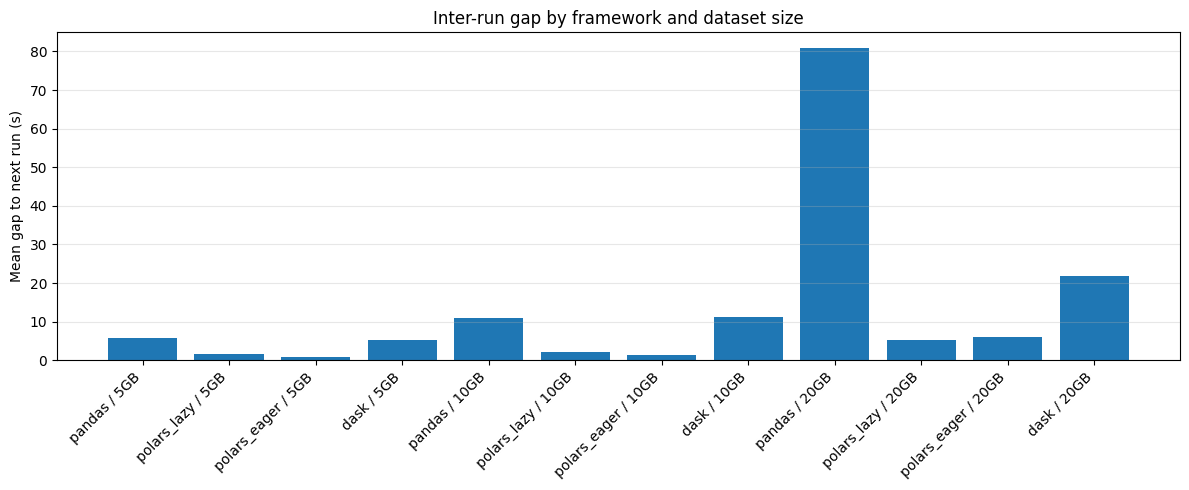

Saved: D:\Polar vs Dask\results\figures\notebook_03_physical_scaling\inter_run_gap_by_framework_size.png


In [75]:
if inter_run_gap.empty:
    print("No inter-run gaps can be computed from the loaded raw log.")
else:
    plot_data = gap_summary.sort_values(["dataset_size", "framework"]).copy()
    plot_data["group_label"] = plot_data["framework"].astype(str) + " / " + plot_data["dataset_size"].astype(str)

    plt.figure(figsize=(12, 5))
    plt.bar(plot_data["group_label"], plot_data["mean_gap_s"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean gap to next run (s)")
    plt.title("Inter-run gap by framework and dataset size")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    output_path = FIGURE_DIR / "inter_run_gap_by_framework_size.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")

### Inter-run Gap Interpretation

Kết quả inter-run gap giúp kiểm tra xem benchmark log có các khoảng thời gian đáng kể nằm ngoài `time_s` hay không.

Nếu `gap_to_next_run_s` nhỏ, các run trong cùng nhóm được thực thi khá liên tục, và `time_s` có thể đại diện tốt cho runtime của workload chính.

Nếu `gap_to_next_run_s` lớn, có thêm thời gian ngoài phần measured runtime. Phần này có thể liên quan đến setup, cleanup, đọc/ghi dữ liệu, scheduler delay, logging hoặc chuẩn bị workload kế tiếp.

Trong notebook này, gap không được cộng vào `mean_time_s`, vì `mean_time_s` chỉ nhằm đo phần workload được benchmark trực tiếp. Gap analysis được giữ riêng như một kiểm tra phụ để phát hiện overhead ngoài vùng đo, tránh trộn measured runtime với các chi phí phụ bên ngoài.

Do các nhóm dataset size có thể được chạy ở những thời điểm khác nhau, phân tích này chỉ so sánh các run nằm trong cùng một nhóm `framework` và `dataset_size`. Không dùng gap giữa các dataset size khác nhau để kết luận về overhead.

### Timing Limitation

Raw log hiện tại chỉ có `timestamp` bắt đầu run và `time_s` đo bên trong benchmark, chưa có `end_time` thật cho từng run.

Vì vậy, notebook chỉ có thể ước lượng `estimated_end_time` và tính inter-run gap giữa các run liên tiếp. Phân tích này hữu ích để phát hiện overhead ngoài vùng đo, nhưng chưa đủ để tách riêng I/O time, setup time, cleanup time và compute time.

Để phân tích timing chính xác hơn trong các benchmark sau, nên ghi thêm các cột như `end_time`, `read_time_s`, `write_time_s`, `setup_time_s`, `cleanup_time_s`, `compute_time_s` và, nếu có thể, disk read/write bytes theo từng run.

## 6. Runtime Scaling

Runtime scaling trả lời câu hỏi đầu tiên: khi input vật lý tăng, framework nào bị chậm lại nhanh nhất và workload nào khuếch đại chi phí lớn nhất?

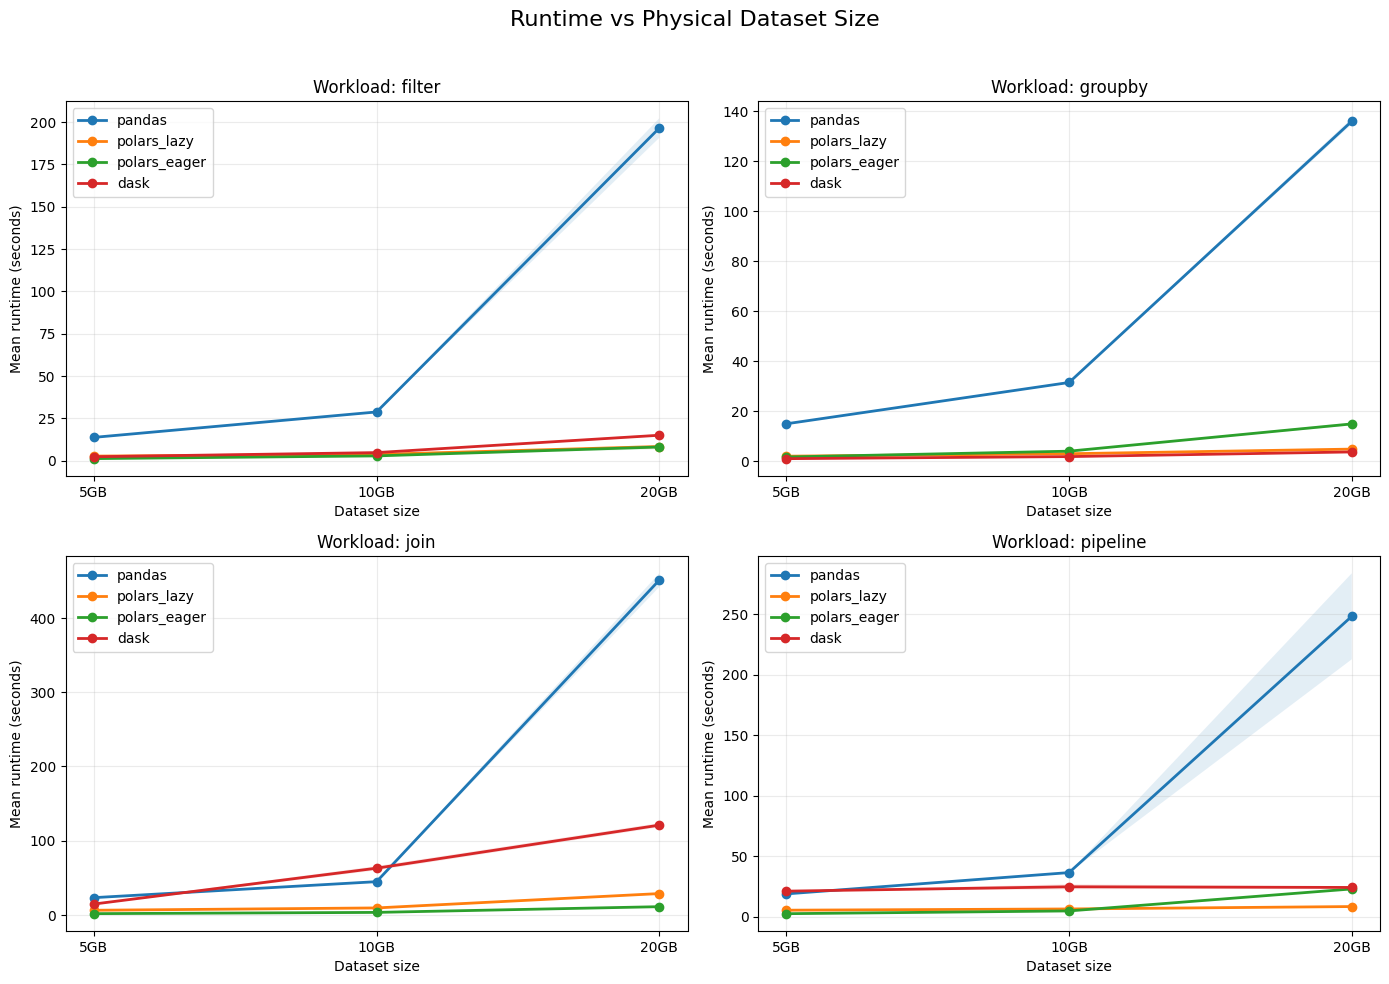

Saved: D:\Polar vs Dask\results\figures\notebook_03_physical_scaling\runtime_vs_size_by_workload.png


In [76]:
def plot_metric_by_workload(data, metric, ylabel, title, filename, marker="o", log_y=False):
    workloads = [
        workload for workload in WORKLOAD_ORDER
        if workload in data["workload"].astype(str).unique()
    ]

    n_cols = 2
    n_rows = int(np.ceil(len(workloads) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.8 * n_rows), squeeze=False)

    size_labels = [
        size for size in SIZE_ORDER
        if size in data["dataset_size"].astype(str).unique()
    ]
    size_to_x = {size: idx for idx, size in enumerate(size_labels)}

    for ax, workload in zip(axes.flat, workloads):
        subset = data[data["workload"].astype(str) == workload]

        for framework in FRAMEWORK_ORDER:
            group = subset[subset["framework"].astype(str) == framework].copy()
            if group.empty:
                continue

            group["size_label"] = group["dataset_size"].astype(str)
            group["x"] = group["size_label"].map(size_to_x)
            group = group.sort_values("x")

            x_values = group["x"].to_numpy()
            y_values = group[metric].to_numpy()

            ax.plot(x_values, y_values, marker=marker, linewidth=2, label=framework)

            std_column = metric.replace("mean_", "std_", 1)
            if std_column in group.columns and group[std_column].notna().any():
                lower = (group[metric] - group[std_column]).clip(lower=0).to_numpy()
                upper = (group[metric] + group[std_column]).to_numpy()
                ax.fill_between(x_values, lower, upper, alpha=0.12)

        ax.set_title(f"Workload: {workload}")
        ax.set_xlabel("Dataset size")
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(size_labels)))
        ax.set_xticklabels(size_labels)
        ax.grid(True, alpha=0.25)

        if log_y:
            ax.set_yscale("log")

        ax.legend()

    for ax in axes.flat[len(workloads):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16, y=1.02)
    fig.tight_layout()

    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_path}")

plot_metric_by_workload(
    summary,
    metric="mean_time_s",
    ylabel="Mean runtime (seconds)",
    title="Runtime vs Physical Dataset Size",
    filename="runtime_vs_size_by_workload.png",
    marker="o",
    log_y=False,
)

### Runtime vs Physical Dataset Size

Biểu đồ này so sánh thời gian chạy trung bình của từng framework khi kích thước dữ liệu tăng từ 5GB lên 20GB.

Nhìn chung, `pandas` có mức tăng runtime mạnh nhất khi dataset lớn hơn, đặc biệt ở các workload `filter`, `groupby`, `join` và `pipeline`. Điều này cho thấy `pandas` bắt đầu gặp bất lợi rõ rệt khi kích thước dữ liệu tăng lên mức 20GB.

Các framework còn lại duy trì runtime thấp hơn đáng kể. `polars_eager` chạy rất nhanh ở các workload đơn giản như `filter` và `join`, trong khi `polars_lazy` thể hiện tốt ở `pipeline`. Với `groupby`, `dask` có runtime thấp nhất ở 20GB, cho thấy partition-based execution có lợi trong workload aggregation.

Tuy nhiên, biểu đồ này mới phản ánh runtime trung bình. Để kết luận framework nào “tốt nhất”, cần xem thêm peak memory, memory efficiency và độ ổn định giữa các lần chạy.

In [77]:
runtime_ranking = (
    summary
    .assign(runtime_rank=lambda data: data.groupby(["workload", "dataset_size"], observed=True)["mean_time_s"].rank(method="min"))
    .sort_values(["workload", "dataset_size", "runtime_rank"])
    [["workload", "dataset_size", "framework", "mean_time_s", "std_time_s", "runtime_rank"]]
)

display(runtime_ranking.round(3))

,workload,dataset_size,framework,mean_time_s,std_time_s,runtime_rank
2,filter,5GB,polars_eager,1.153,0.053,1.0
3,filter,5GB,dask,2.259,0.015,2.0
1,filter,5GB,polars_lazy,2.635,0.539,3.0
0,filter,5GB,pandas,13.697,0.007,4.0
18,filter,10GB,polars_eager,2.753,0.085,1.0
17,filter,10GB,polars_lazy,3.623,0.096,2.0
19,filter,10GB,dask,4.708,0.082,3.0
16,filter,10GB,pandas,28.713,0.103,4.0
34,filter,20GB,polars_eager,8.020,1.290,1.0
33,filter,20GB,polars_lazy,8.288,0.106,2.0


### Runtime Ranking Interpretation

Bảng này xếp hạng các framework theo `mean_time_s` cho từng tổ hợp `workload` và `dataset_size`. Rank thấp hơn nghĩa là runtime trung bình nhanh hơn.

Nhìn chung, `pandas` thường nằm ở rank cuối khi dataset tăng lên, đặc biệt ở mức 20GB. Điều này cho thấy runtime của `pandas` suy giảm rõ khi kích thước vật lý của dữ liệu lớn hơn.

`polars_eager` là framework có runtime tốt nhất ở nhiều workload, đặc biệt là `filter` và `join`. Ở `filter`, `polars_eager` giữ rank 1 ở cả 5GB, 10GB và 20GB. Ở `join`, `polars_eager` cũng đứng đầu ở cả ba kích thước dữ liệu, cho thấy lợi thế rõ trong workload này.

Với `groupby`, `dask` consistently đạt rank 1 ở cả 5GB, 10GB và 20GB. Điều này cho thấy execution model của `dask` phù hợp hơn với workload aggregation trong benchmark này.

Ở `pipeline`, kết quả thay đổi theo dataset size. `polars_eager` nhanh nhất ở 5GB và 10GB, nhưng đến 20GB thì `polars_lazy` đứng đầu. Điều này gợi ý rằng lazy execution có thể phát huy lợi thế hơn khi pipeline workload lớn hơn và có nhiều cơ hội tối ưu execution plan.

Tuy nhiên, ranking này chỉ dựa trên runtime trung bình. Một số trường hợp có `std_time_s` tương đối cao, ví dụ `polars_eager` ở `filter` 20GB và `pandas` ở `pipeline` 20GB. Vì vậy, kết luận runtime nên được đọc cùng với stability metrics như `runtime_cv`, cũng như memory usage và memory efficiency.

## 7. Memory Scaling

Peak memory là metric độc lập với runtime. Một framework có thể nhanh nhưng dùng nhiều RAM, hoặc chậm hơn nhưng memory-stable hơn.

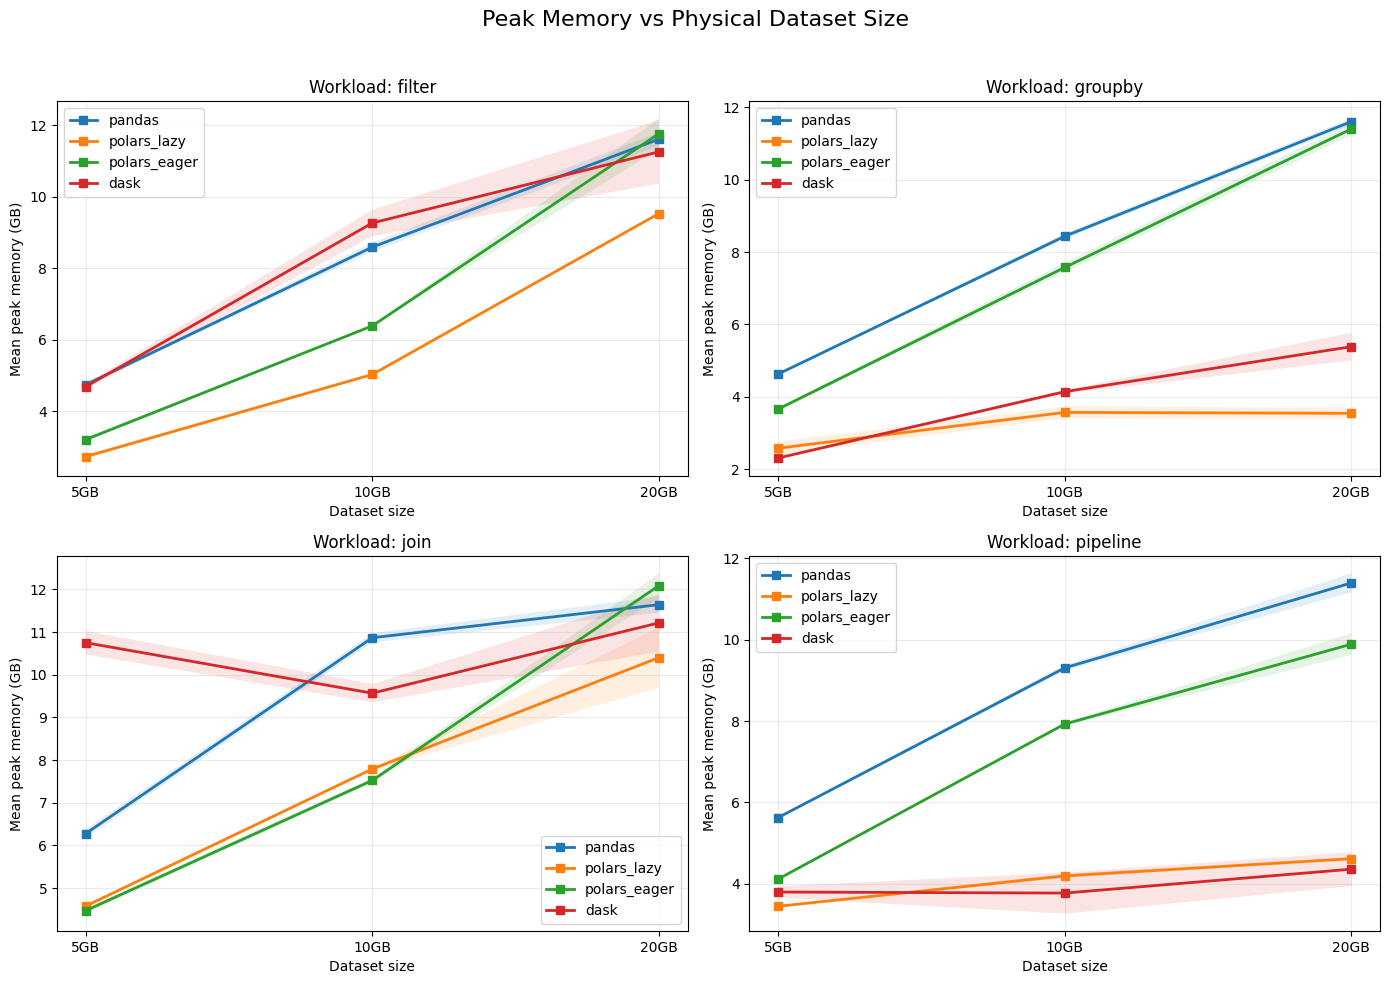

Saved: D:\Polar vs Dask\results\figures\notebook_03_physical_scaling\memory_vs_size_by_workload.png


In [78]:
plot_metric_by_workload(
    summary,
    metric="mean_peak_memory_gb",
    ylabel="Mean peak memory (GB)",
    title="Peak Memory vs Physical Dataset Size",
    filename="memory_vs_size_by_workload.png",
    marker="s",
    log_y=False,
)

### Peak Memory Interpretation

Biểu đồ này so sánh peak memory trung bình của từng framework khi kích thước dữ liệu tăng từ 5GB lên 20GB.

Khác với runtime, memory usage không có một framework duy nhất tốt nhất cho tất cả workload. `polars_lazy` thường dùng ít memory hơn ở nhiều trường hợp, đặc biệt trong `filter`, `groupby`, `join` và `pipeline` ở mức 20GB. Điều này cho thấy lazy execution có lợi thế về memory efficiency khi workload lớn hơn.

`pandas` có xu hướng tăng memory khá mạnh khi dataset size tăng, đặc biệt ở `groupby` và `pipeline`. Ở 20GB, peak memory của `pandas` tiến gần mức 11-12GB ở nhiều workload, cho thấy memory pressure trở nên rõ rệt hơn.

`polars_eager` thường nhanh về runtime nhưng không phải lúc nào cũng tiết kiệm memory. Trong các workload như `groupby`, `join` và `pipeline`, peak memory của `polars_eager` tăng đáng kể ở 20GB. Điều này cho thấy cần đọc runtime cùng với memory để tránh kết luận chỉ dựa trên tốc độ.

`dask` có memory behavior phụ thuộc nhiều vào workload. Với `groupby` và `pipeline`, memory usage tương đối thấp hơn so với `pandas` và `polars_eager`, nhưng ở `filter` và `join` memory vẫn tăng đáng kể.

Nhìn chung, biểu đồ này cho thấy trade-off rõ giữa runtime và memory: framework nhanh nhất không nhất thiết là framework dùng ít memory nhất. Vì vậy, phần phân tích tiếp theo nên xem thêm memory efficiency, ví dụ `memory_per_input_gb`, để đánh giá công bằng hơn theo kích thước input.

In [79]:
memory_ranking = (
    summary
    .assign(memory_rank=lambda data: data.groupby(["workload", "dataset_size"], observed=True)["mean_peak_memory_gb"].rank(method="min"))
    .sort_values(["workload", "dataset_size", "memory_rank"])
    [["workload", "dataset_size", "framework", "mean_peak_memory_gb", "std_peak_memory_gb", "memory_rank"]]
)

display(memory_ranking.round(3))

,workload,dataset_size,framework,mean_peak_memory_gb,std_peak_memory_gb,memory_rank
1,filter,5GB,polars_lazy,2.734,0.059,1.0
2,filter,5GB,polars_eager,3.210,0.062,2.0
3,filter,5GB,dask,4.689,0.077,3.0
0,filter,5GB,pandas,4.745,0.036,4.0
17,filter,10GB,polars_lazy,5.029,0.029,1.0
18,filter,10GB,polars_eager,6.386,0.011,2.0
16,filter,10GB,pandas,8.588,0.128,3.0
19,filter,10GB,dask,9.262,0.370,4.0
33,filter,20GB,polars_lazy,9.526,0.025,1.0
35,filter,20GB,dask,11.250,0.885,2.0


### What this means

Peak memory cho thấy ranking khác đáng kể so với runtime. `polars_eager` rất nhanh ở nhiều workload, nhưng không phải lúc nào cũng là framework tiết kiệm RAM nhất, đặc biệt khi input tăng lên `20GB`.

`polars_lazy` thường có memory behavior tốt hơn trong nhiều workload, nhất là các trường hợp có thể hưởng lợi từ lazy execution, execution plan optimization, hoặc giảm intermediate materialization không cần thiết. `dask` cũng có peak memory thấp ở một số workload như `groupby` và `pipeline`, phù hợp với mô hình partitioned execution.

Điều này cho thấy không nên chọn framework chỉ dựa trên runtime. Với physical scaling, cần đọc runtime cùng với peak memory và normalized memory như `memory_per_input_gb` để hiểu rõ trade-off giữa tốc độ và mức sử dụng RAM.

Caution: `peak_memory` là end-to-end metric, có thể bao gồm đọc parquet, execution, scheduler/optimizer overhead và materialization của output. Không nên diễn giải nó như memory riêng của một operator đơn lẻ.

## 8. Memory per Input GB

Peak memory alone có thể gây hiểu nhầm vì input lớn hơn tự nhiên cần nhiều memory hơn. Để chuẩn hóa áp lực bộ nhớ, notebook dùng metric:

`memory_per_input_gb = mean_peak_memory_gb / dataset_size_gb`

Giá trị thấp hơn nghĩa là framework cần ít RAM hơn cho mỗi GB input. Đây là metric quan trọng cho physical scaling vì nó đo memory efficiency tương đối theo kích thước vật lý.

In [80]:
memory_efficiency = (
    summary
    .dropna(subset=["dataset_size_gb"])
    .sort_values(["workload", "dataset_size_gb", "memory_per_input_gb"])
    [["framework", "workload", "dataset_size", "dataset_size_gb", "mean_peak_memory_gb", "memory_per_input_gb"]]
)

display(memory_efficiency.round(3))

,framework,workload,dataset_size,dataset_size_gb,mean_peak_memory_gb,memory_per_input_gb
1,polars_lazy,filter,5GB,5.0,2.734,0.547
2,polars_eager,filter,5GB,5.0,3.210,0.642
3,dask,filter,5GB,5.0,4.689,0.938
0,pandas,filter,5GB,5.0,4.745,0.949
17,polars_lazy,filter,10GB,10.0,5.029,0.503
18,polars_eager,filter,10GB,10.0,6.386,0.639
16,pandas,filter,10GB,10.0,8.588,0.859
19,dask,filter,10GB,10.0,9.262,0.926
33,polars_lazy,filter,20GB,20.0,9.526,0.476
35,dask,filter,20GB,20.0,11.250,0.562


### Memory Efficiency Interpretation

Bảng này chuẩn hóa peak memory theo kích thước input bằng metric `memory_per_input_gb`. Metric này cho biết mỗi framework cần bao nhiêu GB RAM cho mỗi GB dữ liệu đầu vào.

Nhìn chung, `polars_lazy` và `dask` có memory efficiency tốt hơn ở nhiều workload khi dataset size tăng lên. Ở `groupby`, `polars_lazy` giảm từ khoảng `0.516 GB/GB` ở 5GB xuống `0.177 GB/GB` ở 20GB, cho thấy peak memory không tăng tuyến tính theo input size. `dask` cũng giữ memory efficiency tốt ở `groupby` và `pipeline`, đặc biệt ở `pipeline` 20GB với khoảng `0.218 GB/GB`.

`polars_eager` thường nhanh về runtime nhưng memory efficiency không phải lúc nào cũng tốt nhất. Ở các workload như `groupby`, `join` và `pipeline`, `polars_eager` dùng nhiều memory hơn `polars_lazy` hoặc `dask` khi input lớn hơn.

`pandas` có memory efficiency kém hơn trong nhiều trường hợp, đặc biệt ở các workload nặng như `join` và `pipeline` ở kích thước nhỏ/trung bình. Tuy nhiên, metric này cần được đọc cẩn thận vì một số workload có peak memory gần chạm mức ổn định quanh 11-12GB ở 20GB, làm cho `memory_per_input_gb` giảm khi input tăng.

Vì vậy, `memory_per_input_gb` hữu ích để so sánh memory efficiency theo input size, nhưng không nên thay thế hoàn toàn peak memory tuyệt đối. Hai metric này nên được đọc cùng nhau để hiểu cả mức RAM thực tế cần dùng và khả năng scale theo kích thước dữ liệu.

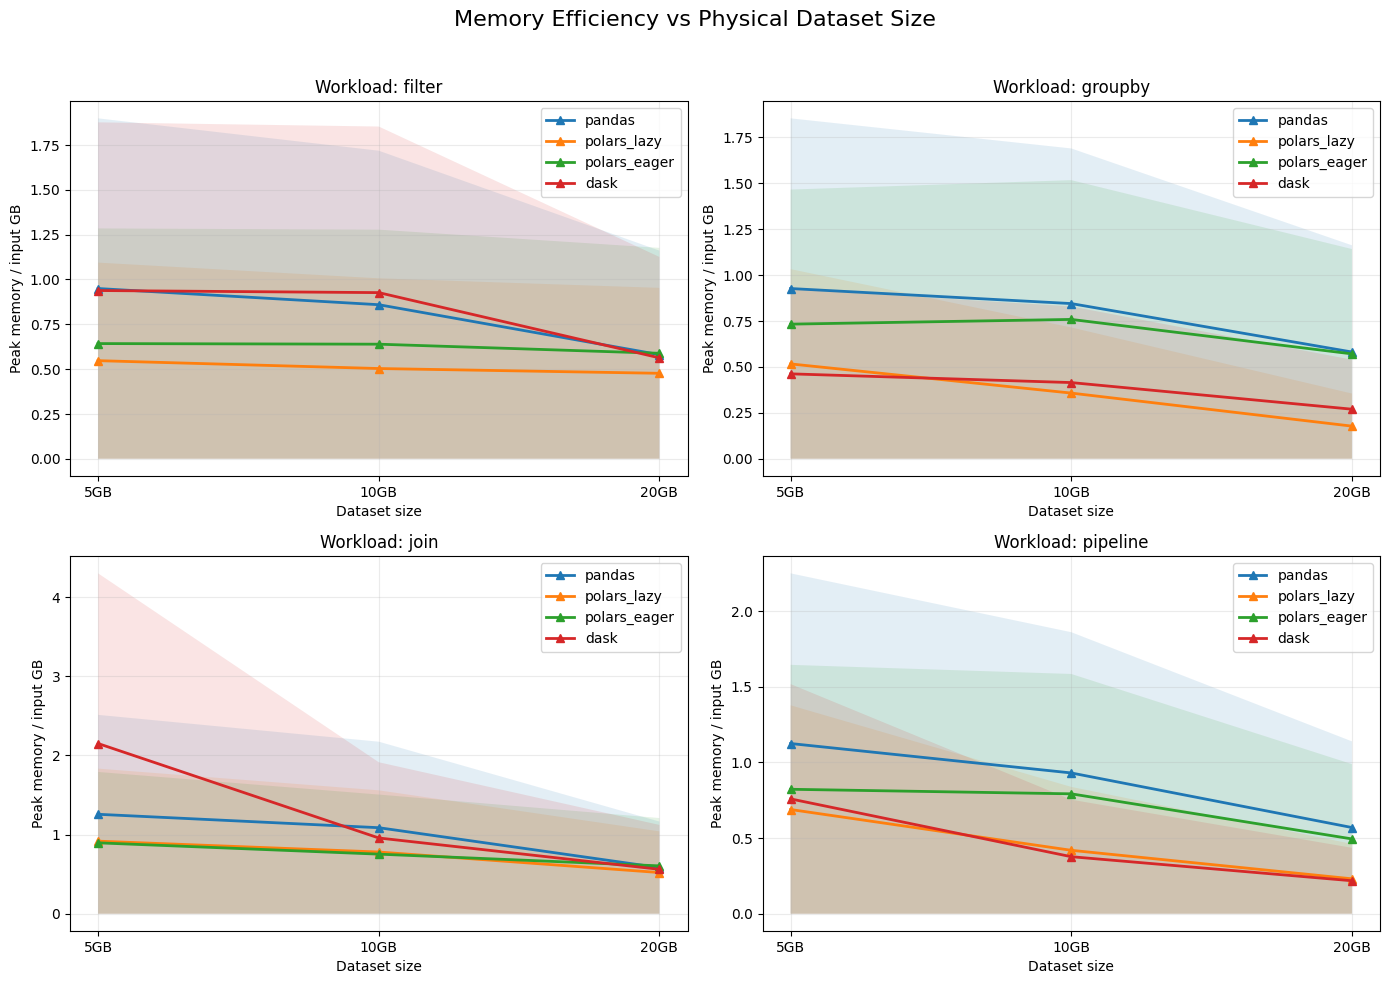

Saved: D:\Polar vs Dask\results\figures\notebook_03_physical_scaling\memory_per_input_gb_by_workload.png


In [81]:
plot_metric_by_workload(
    summary.dropna(subset=["dataset_size_gb"]),
    metric="memory_per_input_gb",
    ylabel="Peak memory / input GB",
    title="Memory Efficiency vs Physical Dataset Size",
    filename="memory_per_input_gb_by_workload.png",
    marker="^",
    log_y=False,
)

### What this means

`memory_per_input_gb` cho thấy framework nào scale memory hiệu quả hơn khi dataset size tăng. Nếu peak memory tăng nhưng `memory_per_input_gb` giảm hoặc ổn định, framework đang dùng RAM tương đối hiệu quả hơn trên input lớn.

Trong chart này, nhiều framework có xu hướng giảm `memory_per_input_gb` khi đi từ `5GB` lên `20GB`. Điều này cho thấy peak memory không tăng tuyến tính theo input size trong nhiều workload. `polars_lazy` và `dask` thường nằm ở vùng thấp hơn trong các workload như `groupby` và `pipeline`, trong khi `pandas` và `polars_eager` thường cao hơn ở một số case.

Metric này đặc biệt hữu ích để tránh kết luận sai từ peak memory tuyệt đối. Ví dụ, một run `20GB` có peak memory cao hơn `5GB` là bình thường; câu hỏi quan trọng hơn là RAM trên mỗi GB input có tăng, giảm hay bùng lên.

Caution: metric này vẫn phụ thuộc workload output size. `join` và `pipeline` có thể tạo intermediate/output lớn hơn `filter` và `groupby`, nên không nên so sánh memory efficiency giữa workload khác nhau mà không đọc bối cảnh operator.

## 9. Slowdown Ratio vs 5GB

Slowdown ratio so sánh runtime của từng size với baseline nhỏ nhất hiện có. Trong dữ liệu hiện tại, baseline là `5GB`.

In [82]:
available_size_order = [size for size in SIZE_ORDER if size in summary["dataset_size"].astype(str).unique()]
BASELINE_SIZE = "5GB" if "5GB" in available_size_order else available_size_order[0]

baseline = (
    summary[summary["dataset_size"].astype(str) == BASELINE_SIZE]
    [["framework", "workload", "mean_time_s", "mean_peak_memory_gb"]]
    .rename(columns={
        "mean_time_s": "baseline_time_s",
        "mean_peak_memory_gb": "baseline_peak_memory_gb",
    })
)

summary_ratio = summary.merge(baseline, on=["framework", "workload"], how="left")
summary_ratio["runtime_slowdown_ratio"] = summary_ratio["mean_time_s"] / summary_ratio["baseline_time_s"]
summary_ratio["memory_growth_ratio"] = summary_ratio["mean_peak_memory_gb"] / summary_ratio["baseline_peak_memory_gb"]

slowdown_table = summary_ratio.pivot_table(
    index=["framework", "workload"],
    columns="dataset_size",
    values="runtime_slowdown_ratio",
    observed=True,
)

memory_growth_table = summary_ratio.pivot_table(
    index=["framework", "workload"],
    columns="dataset_size",
    values="memory_growth_ratio",
    observed=True,
)

print(f"Baseline size: {BASELINE_SIZE}")
display(slowdown_table.round(2))
display(memory_growth_table.round(2))

Baseline size: 5GB


dataset_size           5GB  10GB   20GB
framework    workload                  
pandas       filter    1.0  2.10  14.34
             groupby   1.0  2.10   9.06
             join      1.0  1.92  19.35
             pipeline  1.0  1.93  13.14
polars_lazy  filter    1.0  1.37   3.15
             groupby   1.0  1.48   2.38
             join      1.0  1.50   4.56
             pipeline  1.0  1.19   1.55
polars_eager filter    1.0  2.39   6.95
             groupby   1.0  2.34   8.60
             join      1.0  1.96   6.35
             pipeline  1.0  1.90   9.04
dask         filter    1.0  2.08   6.62
             groupby   1.0  1.78   3.53
             join      1.0  4.29   8.24
             pipeline  1.0  1.17   1.14

dataset_size           5GB  10GB  20GB
framework    workload                 
pandas       filter    1.0  1.81  2.45
             groupby   1.0  1.82  2.51
             join      1.0  1.73  1.85
             pipeline  1.0  1.65  2.03
polars_lazy  filter    1.0  1.84  3.48
             groupby   1.0  1.38  1.37
             join      1.0  1.70  2.27
             pipeline  1.0  1.22  1.34
polars_eager filter    1.0  1.99  3.66
             groupby   1.0  2.07  3.12
             join      1.0  1.68  2.70
             pipeline  1.0  1.93  2.40
dask         filter    1.0  1.98  2.40
             groupby   1.0  1.79  2.33
             join      1.0  0.89  1.04
             pipeline  1.0  0.99  1.15

### What this means

Ratio table giúp so sánh mức tăng tương đối so với baseline `5GB`.

Với runtime, input tăng từ `5GB` lên `20GB` là khoảng 4 lần. Nếu runtime tăng gần 4 lần, scaling có thể xem là gần tuyến tính trong range này. Nếu runtime tăng lớn hơn nhiều, đó là dấu hiệu nonlinear slowdown, có thể liên quan đến memory pressure, materialization, shuffle overhead hoặc execution strategy.

Trong kết quả này, `pandas` có runtime slowdown mạnh nhất ở nhiều workload, đặc biệt tại `20GB`. Ngược lại, `polars_lazy` và `dask` giữ slowdown thấp hơn trong một số workload như `pipeline`.

Với memory ratio, cần đọc riêng: nó phản ánh peak memory tăng bao nhiêu lần so với `5GB`, không phải runtime degradation. Memory ratio tăng chậm hơn input size có thể cho thấy memory efficiency tốt hơn ở input lớn.

Caution: ratio hiện dùng `5GB` làm baseline vì notebook chưa có `1GB`. Nếu sau này thêm `1GB`, cần ghi chú rõ khi thay đổi baseline.

## 10. Speedup vs Pandas

Speedup dùng Pandas làm baseline trong cùng workload và cùng size:

`speedup_vs_pandas = pandas_mean_time_s / framework_mean_time_s`

Giá trị lớn hơn 1 nghĩa là framework nhanh hơn Pandas.

In [83]:
pandas_baseline = (
    summary[summary["framework"].astype(str) == "pandas"]
    [["workload", "dataset_size", "mean_time_s", "mean_peak_memory_gb"]]
    .rename(columns={
        "mean_time_s": "pandas_time_s",
        "mean_peak_memory_gb": "pandas_peak_memory_gb",
    })
)

comparison = summary.merge(pandas_baseline, on=["workload", "dataset_size"], how="left")
comparison["speedup_vs_pandas"] = comparison["pandas_time_s"] / comparison["mean_time_s"]
comparison["memory_ratio_vs_pandas"] = comparison["mean_peak_memory_gb"] / comparison["pandas_peak_memory_gb"]

speedup_table = comparison.pivot_table(
    index=["workload", "dataset_size"],
    columns="framework",
    values="speedup_vs_pandas",
    observed=True,
)

memory_ratio_table = comparison.pivot_table(
    index=["workload", "dataset_size"],
    columns="framework",
    values="memory_ratio_vs_pandas",
    observed=True,
)

display(speedup_table.round(2))
display(memory_ratio_table.round(2))

framework              pandas  polars_lazy  polars_eager   dask
workload dataset_size                                          
filter   5GB              1.0         5.20         11.88   6.06
         10GB             1.0         7.93         10.43   6.10
         20GB             1.0        23.69         24.48  13.13
groupby  5GB              1.0         7.30          8.63  14.10
         10GB             1.0        10.36          7.76  16.64
         20GB             1.0        27.80          9.09  36.18
join     5GB              1.0         3.70         13.30   1.59
         10GB             1.0         4.75         13.07   0.71
         20GB             1.0        15.67         40.50   3.73
pipeline 5GB              1.0         3.48          7.43   0.89
         10GB             1.0         5.66          7.57   1.47
         20GB             1.0        29.41         10.80  10.25

framework              pandas  polars_lazy  polars_eager  dask
workload dataset_size                                         
filter   5GB              1.0         0.58          0.68  0.99
         10GB             1.0         0.59          0.74  1.08
         20GB             1.0         0.82          1.01  0.97
groupby  5GB              1.0         0.56          0.79  0.50
         10GB             1.0         0.42          0.90  0.49
         20GB             1.0         0.31          0.98  0.46
join     5GB              1.0         0.73          0.71  1.71
         10GB             1.0         0.72          0.69  0.88
         20GB             1.0         0.89          1.04  0.96
pipeline 5GB              1.0         0.61          0.73  0.67
         10GB             1.0         0.45          0.85  0.40
         20GB             1.0         0.40          0.87  0.38

### What this means

`speedup_vs_pandas` cho thấy lợi thế runtime của các framework so với Pandas trong từng workload và dataset size. Giá trị lớn hơn `1.0` nghĩa là framework chạy nhanh hơn Pandas, còn giá trị nhỏ hơn `1.0` nghĩa là chậm hơn Pandas.

Nhìn chung, Polars có speedup rất rõ so với Pandas, đặc biệt ở các workload `filter`, `join` và `pipeline` khi dataset tăng lên `20GB`. `polars_eager` nổi bật ở các workload cần tốc độ thực thi trực tiếp như `filter` và `join`, trong khi `polars_lazy` có lợi thế mạnh ở `pipeline` 20GB.

`dask` có behavior phụ thuộc workload hơn. Nó rất mạnh ở `groupby`, nhưng không luôn nhanh hơn Pandas trong mọi workload, ví dụ một số case `join` hoặc `pipeline` ở size nhỏ/trung bình. Điều này cho thấy partitioned execution có lợi trong một số pattern, nhưng cũng có thể thêm overhead ở workload khác.

Bảng `memory_ratio_vs_pandas` cần được đọc riêng với ý nghĩa khác: giá trị nhỏ hơn `1.0` nghĩa là dùng ít peak memory hơn Pandas, còn giá trị lớn hơn `1.0` nghĩa là dùng nhiều hơn Pandas. Kết quả cho thấy speedup runtime không luôn đi cùng memory saving. Một framework có thể nhanh hơn Pandas rất nhiều nhưng dùng memory tương đương hoặc cao hơn.

Vì vậy, speedup nên được đọc cùng `memory_ratio_vs_pandas`, `memory_per_input_gb` và runtime-memory trade-off plot để đánh giá framework theo cả tốc độ lẫn memory behavior.

## 11. Runtime-Memory Trade-off

Framework tốt nhất không phải lúc nào cũng là framework nhanh nhất. Với physical scaling, lựa chọn thực tế nên tối ưu cả runtime và peak memory.

Điểm càng gần góc dưới trái càng tốt: runtime thấp và peak memory thấp. Điểm bị một framework khác vừa nhanh hơn vừa ít memory hơn thì bị dominated.

In [84]:
def pareto_frontier(group, x_col="mean_peak_memory_gb", y_col="mean_time_s"):
    rows = []
    for idx, row in group.iterrows():
        dominated = ((group[x_col] <= row[x_col]) & (group[y_col] <= row[y_col]) & ((group[x_col] < row[x_col]) | (group[y_col] < row[y_col]))).any()
        if not dominated:
            rows.append(idx)
    return group.loc[rows]

pareto_rows = []
for (workload, dataset_size), group in summary.groupby(["workload", "dataset_size"], observed=True):
    frontier = pareto_frontier(group)
    pareto_rows.append(frontier.assign(is_pareto=True))

pareto_summary = pd.concat(pareto_rows, ignore_index=True) if pareto_rows else pd.DataFrame()

display(
    pareto_summary[["workload", "dataset_size", "framework", "mean_time_s", "mean_peak_memory_gb", "memory_per_input_gb"]]
    .sort_values(["workload", "dataset_size", "mean_time_s"])
    .round(3)
)

,workload,dataset_size,framework,mean_time_s,mean_peak_memory_gb,memory_per_input_gb
1,filter,5GB,polars_eager,1.153,3.210,0.642
0,filter,5GB,polars_lazy,2.635,2.734,0.547
3,filter,10GB,polars_eager,2.753,6.386,0.639
2,filter,10GB,polars_lazy,3.623,5.029,0.503
5,filter,20GB,polars_eager,8.020,11.757,0.588
4,filter,20GB,polars_lazy,8.288,9.526,0.476
6,groupby,5GB,dask,1.065,2.307,0.461
8,groupby,10GB,dask,1.895,4.141,0.414
7,groupby,10GB,polars_lazy,3.042,3.569,0.357
10,groupby,20GB,dask,3.759,5.385,0.269


### Runtime-Memory Trade-off Interpretation

Bảng này liệt kê các framework nằm trên runtime-memory trade-off frontier cho từng tổ hợp `workload` và `dataset_size`. Một framework được giữ lại nếu nó không bị framework khác đồng thời nhanh hơn và dùng ít memory hơn.

Kết quả cho thấy không có một framework duy nhất tối ưu cho mọi workload. `polars_eager` thường nằm trên frontier vì có runtime rất thấp, đặc biệt ở `filter`, `join` và `pipeline` ở 5GB/10GB. Tuy nhiên, nó thường đánh đổi bằng peak memory cao hơn so với `polars_lazy`.

`polars_lazy` thường xuất hiện trên frontier nhờ memory usage thấp hơn, đặc biệt khi dataset lớn hơn. Ở một số case như `filter` 20GB hoặc `pipeline` 20GB, `polars_lazy` gần như đạt được cả runtime tốt và memory thấp, nên là lựa chọn cân bằng hơn.

`dask` xuất hiện trên frontier chủ yếu ở các workload mà partitioned execution giúp giảm memory hoặc tăng hiệu quả aggregation, ví dụ `groupby` và `pipeline`. Tuy nhiên, ở một số workload khác như `join`, Dask không nằm trên frontier vì runtime cao hơn mà không đem lại lợi thế memory đủ lớn.

Điểm chính là framework nhanh nhất không luôn là framework tốt nhất nếu xét memory. Với physical scaling, nên chọn framework dựa trên trade-off giữa `mean_time_s`, `mean_peak_memory_gb` và `memory_per_input_gb`, thay vì chỉ dựa trên runtime ranking.

In [92]:
def plot_runtime_memory_tradeoff_for_workload(workload):
    data = summary[summary["workload"].astype(str) == workload]

    if data.empty:
        print(f"No data for workload: {workload}")
        return

    plt.figure(figsize=(8, 6))

    for framework in FRAMEWORK_ORDER:
        sub = data[data["framework"].astype(str) == framework]

        if sub.empty:
            continue

        plt.scatter(
            sub["mean_peak_memory_gb"],
            sub["mean_time_s"],
            s=90,
            label=framework,
            alpha=0.85,
        )

        for _, row in sub.iterrows():
            plt.annotate(
                str(row["dataset_size"]),
                (row["mean_peak_memory_gb"], row["mean_time_s"]),
                textcoords="offset points",
                xytext=(5, 4),
                fontsize=8,
            )

    plt.xlabel("Mean peak memory (GB)")
    plt.ylabel("Mean runtime (s)")
    plt.title(f"Runtime-memory trade-off: {workload}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    output_path = FIGURE_DIR / f"runtime_memory_tradeoff_{workload}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_path}")

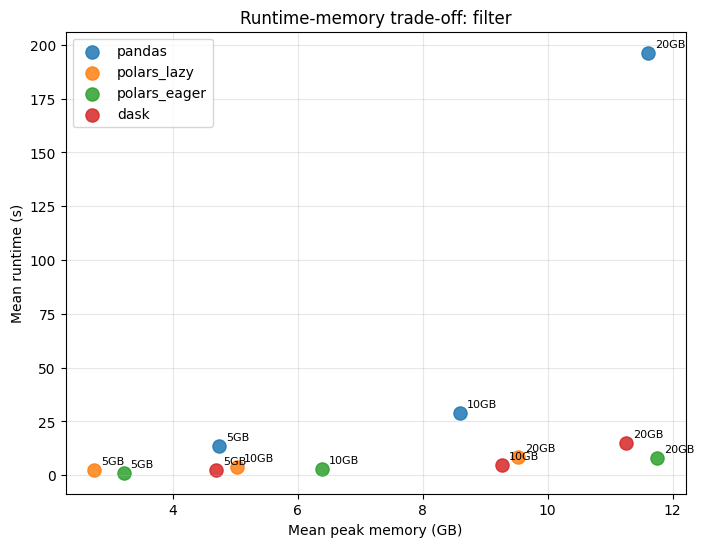

Saved: D:\Polar vs Dask\results\figures\notebook_03_physical_scaling\runtime_memory_tradeoff_filter.png


In [93]:
plot_runtime_memory_tradeoff_for_workload("filter")

### Filter Trade-off

Biểu đồ này cho thấy trade-off giữa runtime và peak memory cho workload `filter`. Điểm càng gần góc dưới bên trái thì càng tốt, vì vừa có runtime thấp vừa dùng ít memory.

Ở `filter`, `polars_eager` và `polars_lazy` đều nằm ở vùng trade-off tốt hơn so với `pandas` và `dask`. `polars_eager` thường nhanh nhất, đặc biệt ở `5GB` và `10GB`, trong khi `polars_lazy` dùng ít memory hơn ở cả ba kích thước dữ liệu.

Ở `20GB`, `pandas` trở thành điểm kém nhất rõ rệt: runtime tăng rất mạnh trong khi peak memory cũng cao. Điều này cho thấy `pandas` bị dominate trong workload này, vì có framework khác vừa nhanh hơn vừa dùng ít hoặc tương đương memory hơn.

Kết luận chính: với workload `filter`, `polars_eager` phù hợp nếu ưu tiên tốc độ, còn `polars_lazy` là lựa chọn cân bằng hơn nếu cần giảm peak memory.

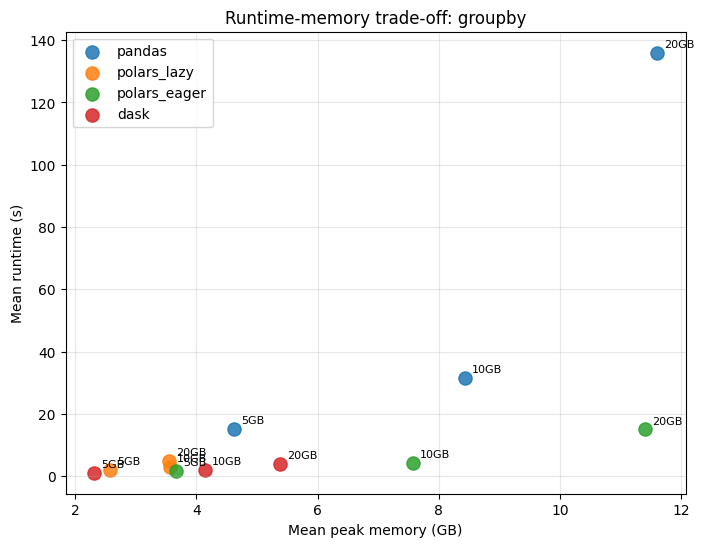

Saved: D:\Polar vs Dask\results\figures\notebook_03_physical_scaling\runtime_memory_tradeoff_groupby.png


In [96]:
plot_runtime_memory_tradeoff_for_workload("groupby")

### Groupby Trade-off

Biểu đồ này cho thấy trade-off giữa runtime và peak memory cho workload `groupby`. Điểm càng gần góc dưới bên trái thì càng tốt, vì vừa chạy nhanh vừa dùng ít memory.

Ở `groupby`, `dask` có runtime tốt nhất ở cả ba kích thước dữ liệu, đặc biệt khi dataset tăng lên `20GB`. Điều này cho thấy partitioned execution của `dask` phù hợp với workload aggregation trong benchmark này.

`polars_lazy` dùng memory rất thấp và giữ runtime tương đối tốt, nhất là ở `10GB` và `20GB`. So với `dask`, `polars_lazy` chậm hơn một chút ở runtime nhưng tiết kiệm memory hơn, nên đây là lựa chọn cân bằng nếu ưu tiên memory efficiency.

`pandas` bị dominate rõ rệt ở workload này: runtime tăng mạnh khi dataset lớn hơn và peak memory cũng cao. `polars_eager` nhanh hơn `pandas`, nhưng ở `20GB` dùng memory cao hơn nhiều so với `polars_lazy` và `dask`.

Kết luận chính: với `groupby`, `dask` là lựa chọn tốt nhất nếu ưu tiên runtime, còn `polars_lazy` là lựa chọn tốt hơn nếu ưu tiên memory efficiency.

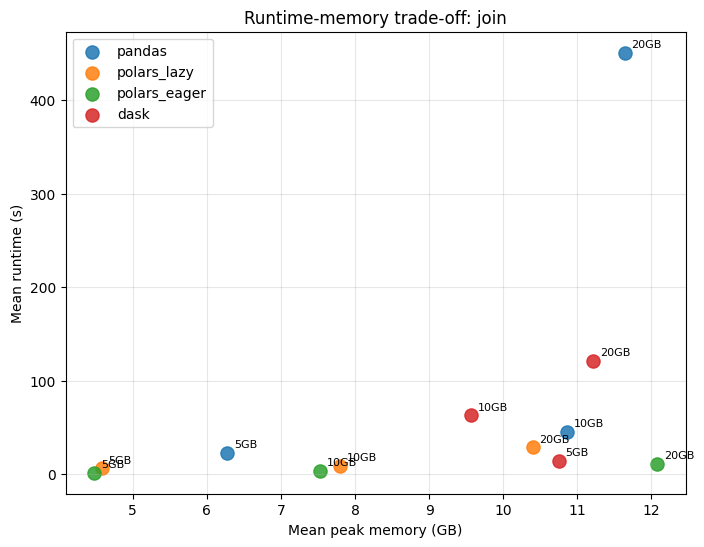

Saved: D:\Polar vs Dask\results\figures\notebook_03_physical_scaling\runtime_memory_tradeoff_join.png


In [95]:
plot_runtime_memory_tradeoff_for_workload("join")

### Join Trade-off

Biểu đồ này cho thấy trade-off giữa runtime và peak memory cho workload `join`. Đây là workload nặng hơn vì join có thể tạo intermediate data hoặc output lớn hơn so với các workload đơn giản như `filter`.

Ở `join`, `polars_eager` có lợi thế runtime rất rõ. Nó là framework nhanh nhất ở cả `5GB`, `10GB` và `20GB`, nhưng khi dataset tăng lên `20GB`, peak memory cũng tăng lên mức cao nhất trong nhóm.

`polars_lazy` chậm hơn `polars_eager`, nhưng dùng ít memory hơn ở `20GB`. Điều này cho thấy `polars_lazy` là lựa chọn cân bằng hơn nếu memory là giới hạn chính, còn `polars_eager` phù hợp hơn nếu ưu tiên tốc độ.

`pandas` bị ảnh hưởng mạnh ở `20GB`: runtime tăng rất lớn trong khi peak memory cũng cao. `dask` cũng không phải lựa chọn tốt cho `join` trong benchmark này, vì runtime cao hơn đáng kể so với Polars, dù memory không thấp hơn đủ để bù lại.

Kết luận chính: với workload `join`, `polars_eager` là lựa chọn tốt nhất nếu ưu tiên runtime, còn `polars_lazy` đáng cân nhắc ở size lớn nếu cần giảm peak memory.

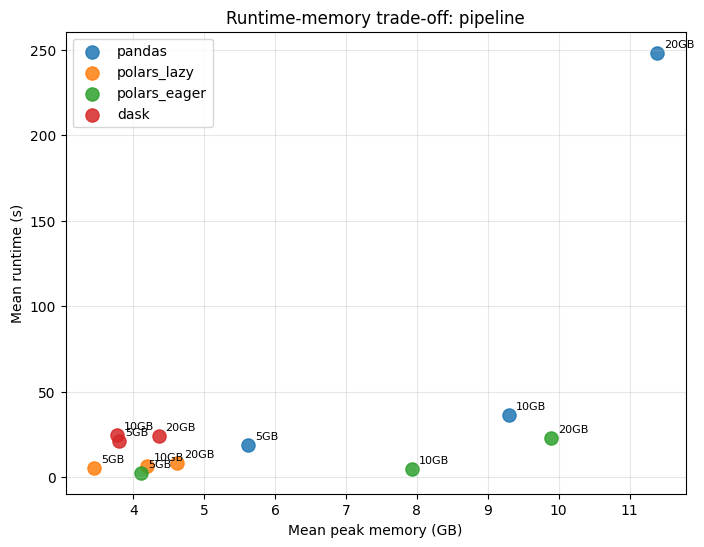

Saved: D:\Polar vs Dask\results\figures\notebook_03_physical_scaling\runtime_memory_tradeoff_pipeline.png


In [94]:
plot_runtime_memory_tradeoff_for_workload("pipeline")

### Pipeline Trade-off

Biểu đồ này cho thấy trade-off giữa runtime và peak memory cho workload `pipeline`. Đây là workload tổng hợp hơn, nên kết quả phản ánh không chỉ tốc độ của một operator đơn lẻ mà còn cả khả năng tối ưu execution plan, giảm intermediate materialization và quản lý memory qua nhiều bước xử lý.

Ở `5GB` và `10GB`, `polars_eager` có runtime tốt nhất, nhưng peak memory tăng khá rõ khi dataset lớn hơn. Điều này cho thấy `polars_eager` phù hợp khi ưu tiên tốc độ ở size nhỏ và trung bình, nhưng không phải lựa chọn tiết kiệm memory nhất.

Ở `20GB`, `polars_lazy` trở thành lựa chọn cân bằng nhất: runtime thấp nhất trong nhóm và peak memory cũng thấp hơn nhiều so với `pandas` và `polars_eager`. Điều này cho thấy lazy execution có lợi thế rõ hơn khi pipeline lớn hơn và có nhiều cơ hội tối ưu execution plan.

`dask` có peak memory thấp ở cả ba size, đặc biệt gần với `polars_lazy`, nhưng runtime cao hơn đáng kể. Vì vậy, `dask` có thể phù hợp nếu memory là ưu tiên chính, nhưng trong benchmark này không cạnh tranh bằng `polars_lazy` về runtime cho pipeline.

`pandas` bị dominate rõ ở `20GB`: vừa chậm hơn nhiều vừa dùng peak memory cao hơn. Điều này cho thấy `pandas` không scale tốt với pipeline workload ở input lớn.

Kết luận chính: với workload `pipeline`, `polars_eager` tốt ở size nhỏ/trung bình nếu ưu tiên runtime, còn `polars_lazy` là lựa chọn tốt nhất ở `20GB` nhờ cân bằng tốt giữa runtime và memory.

### What this means

Trade-off plot giúp tránh câu hỏi đơn giản “framework nào nhanh nhất?”. Một framework có runtime thấp nhưng dùng nhiều RAM có thể kém phù hợp hơn trong môi trường constrained memory.

Pareto table cho biết các lựa chọn không bị dominated trong từng `workload` và `dataset_size`. Đây là nhóm framework đáng cân nhắc thực tế: không có framework khác trong cùng điều kiện vừa nhanh hơn vừa dùng ít memory hơn.

Caution: Pareto frontier được tính theo `mean_time_s` và `mean_peak_memory_gb`. Nếu variance cao, một điểm Pareto có thể không ổn định trong thực tế; vì vậy cần đọc tiếp stability analysis trước khi đưa ra kết luận cuối cùng.

## 12. Stability / Variance Analysis

Mean runtime không đủ để so sánh framework. Một framework nhanh trung bình nhưng variance cao có thể khó dự đoán hơn trong workload gần production.

Notebook dùng coefficient of variation:

`runtime_cv = std_time_s / mean_time_s`  
`memory_cv = std_peak_memory_gb / mean_peak_memory_gb`

Giá trị cao hơn nghĩa là execution kém ổn định hơn giữa các repeated runs.

In [86]:
stability = (
    summary
    [[
        "framework", "workload", "dataset_size", "dataset_size_gb",
        "mean_time_s", "std_time_s", "runtime_cv",
        "mean_peak_memory_gb", "std_peak_memory_gb", "memory_cv",
        "n_runs",
    ]]
    .sort_values(["workload", "dataset_size", "runtime_cv"], ascending=[True, True, False])
)

display(stability.round(4))

,framework,workload,dataset_size,dataset_size_gb,mean_time_s,std_time_s,runtime_cv,mean_peak_memory_gb,std_peak_memory_gb,memory_cv,n_runs
1,polars_lazy,filter,5GB,5.0,2.6350,0.5390,0.2046,2.7336,0.0588,0.0215,3
2,polars_eager,filter,5GB,5.0,1.1533,0.0532,0.0461,3.2102,0.0623,0.0194,3
3,dask,filter,5GB,5.0,2.2590,0.0148,0.0066,4.6893,0.0766,0.0163,3
0,pandas,filter,5GB,5.0,13.6972,0.0073,0.0005,4.7451,0.0360,0.0076,3
18,polars_eager,filter,10GB,10.0,2.7534,0.0854,0.0310,6.3864,0.0110,0.0017,3
17,polars_lazy,filter,10GB,10.0,3.6228,0.0964,0.0266,5.0289,0.0289,0.0058,3
19,dask,filter,10GB,10.0,4.7076,0.0821,0.0174,9.2620,0.3695,0.0399,3
16,pandas,filter,10GB,10.0,28.7129,0.1030,0.0036,8.5880,0.1283,0.0149,3
34,polars_eager,filter,20GB,20.0,8.0203,1.2904,0.1609,11.7574,0.4278,0.0364,3
35,dask,filter,20GB,20.0,14.9540,0.6457,0.0432,11.2498,0.8852,0.0787,3


### Stability Analysis Interpretation

Bảng này kiểm tra độ ổn định của runtime và memory qua 3 lần chạy cho mỗi tổ hợp `framework`, `workload` và `dataset_size`.

`runtime_cv` và `memory_cv` là hệ số biến thiên, được tính bằng `std / mean`. Giá trị càng thấp nghĩa là kết quả càng ổn định giữa các lần chạy. Metric này giúp kiểm tra xem một framework nhanh hoặc tiết kiệm memory có thật sự ổn định hay chỉ tốt trong một vài run.

Nhìn chung, phần lớn các tổ hợp có `runtime_cv` và `memory_cv` thấp, cho thấy benchmark khá ổn định. Tuy nhiên, có một số case cần đọc cẩn thận hơn, ví dụ `polars_lazy` ở `filter` 5GB có `runtime_cv` cao, `polars_eager` ở `filter` 20GB có runtime dao động lớn hơn, và `pandas` ở `pipeline` 20GB cũng có `runtime_cv` cao. Những case này không nên được kết luận quá mạnh chỉ dựa trên mean runtime.

Với memory, một số case của `dask` có `memory_cv` cao hơn, đặc biệt ở `pipeline` và một số workload lớn hơn. Điều này cho thấy peak memory của Dask có thể dao động tùy partition scheduling hoặc execution path.

Caution: mỗi tổ hợp hiện chỉ có 3 runs, nên `std` và `cv` chỉ là chỉ báo ban đầu về stability, chưa phải thống kê đủ mạnh. Nếu một kết luận quan trọng phụ thuộc vào các case có CV cao, nên tăng số lần chạy để xác nhận lại.

In [87]:
stability_flags = stability[(stability["runtime_cv"] > 0.10) | (stability["memory_cv"] > 0.10)].copy()

if stability_flags.empty:
    print("No framework/workload/size cells have runtime_cv or memory_cv above 0.10.")
else:
    print("Cells with runtime_cv or memory_cv above 0.10:")
    display(stability_flags.round(4))

Cells with runtime_cv or memory_cv above 0.10:


,framework,workload,dataset_size,dataset_size_gb,mean_time_s,std_time_s,runtime_cv,mean_peak_memory_gb,std_peak_memory_gb,memory_cv,n_runs
1,polars_lazy,filter,5GB,5.0,2.6350,0.5390,0.2046,2.7336,0.0588,0.0215,3
34,polars_eager,filter,20GB,20.0,8.0203,1.2904,0.1609,11.7574,0.4278,0.0364,3
31,dask,pipeline,10GB,10.0,24.7833,2.1050,0.0849,3.7681,0.5069,0.1345,3
44,pandas,pipeline,20GB,20.0,248.3173,35.5275,0.1431,11.3927,0.2354,0.0207,3


### High-Variance Cells

Bảng này liệt kê các tổ hợp có `runtime_cv` hoặc `memory_cv` lớn hơn `0.10`. Đây là các case cần đọc cẩn thận hơn vì kết quả giữa 3 runs dao động tương đối mạnh.

Chỉ có 4 cell vượt ngưỡng này, cho thấy phần lớn benchmark có độ ổn định tốt. Các case đáng chú ý gồm `polars_lazy` ở `filter` 5GB, `polars_eager` ở `filter` 20GB, `dask` ở `pipeline` 10GB và `pandas` ở `pipeline` 20GB.

Trong đó, `polars_lazy` ở `filter` 5GB và `polars_eager` ở `filter` 20GB chủ yếu bị flag do `runtime_cv` cao. `dask` ở `pipeline` 10GB chủ yếu bị flag do `memory_cv` cao, còn `pandas` ở `pipeline` 20GB bị flag do runtime dao động lớn.

Caution: mỗi cell chỉ có 3 runs, nên các CV này là tín hiệu cảnh báo ban đầu chứ chưa đủ để kết luận thống kê mạnh. Nếu một kết luận quan trọng phụ thuộc vào các cell này, nên chạy thêm nhiều lần để xác nhận.

### What this means

Stability analysis giúp kiểm tra liệu ranking runtime và memory có đáng tin không. Nếu một framework nhanh nhất nhưng `runtime_cv` cao, kết luận nên viết thận trọng hơn vì repeated runs chưa đủ ổn định.

Trong benchmark này, phần lớn cấu hình có `runtime_cv` và `memory_cv` thấp, nhưng vẫn có một vài cell cần chú ý. Một số dao động xuất hiện ở `filter`, ví dụ `polars_lazy` 5GB và `polars_eager` 20GB; ngoài ra `pipeline` cũng có variance cao hơn ở một số framework như `dask` 10GB và `pandas` 20GB.

Variance có thể đến từ scheduler, disk cache, memory allocation, garbage collection, pagefile hoặc khác biệt nhỏ giữa các lần chạy. Các workload như `join` và `pipeline` vẫn cần được đọc kỹ hơn vì chúng thường tạo nhiều intermediate state hơn, nhưng không nên giả định chỉ hai workload này mới có variance.

Caution: chỉ có 3 runs cho mỗi cấu hình, nên CV ở đây là chỉ báo ban đầu, không phải kiểm định thống kê mạnh. Nếu kết luận quan trọng phụ thuộc vào một cell có CV cao, nên chạy thêm nhiều runs để xác nhận.

## 13. Scaling Slopes

Scaling slope ước lượng độ nhạy runtime theo kích thước vật lý bằng hồi quy log-log trên các điểm có đơn vị GB. Slope gần 1 gợi ý tăng gần tuyến tính theo size; slope lớn hơn 1 gợi ý nonlinear slowdown.

In [88]:
slope_rows = []

for (framework, workload), group in summary.groupby(["framework", "workload"], observed=True):
    group = group.dropna(subset=["dataset_size_gb", "mean_time_s"])
    group = group[(group["dataset_size_gb"] > 0) & (group["mean_time_s"] > 0)]

    if len(group) >= 2:
        x = np.log(group["dataset_size_gb"].to_numpy())
        y = np.log(group["mean_time_s"].to_numpy())

        slope, intercept = np.polyfit(x, y, 1)
        y_pred = slope * x + intercept

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        slope_rows.append({
            "framework": framework,
            "workload": workload,
            "runtime_scaling_slope": slope,
            "r_squared": r_squared,
            "n_points": len(group),
            "min_size_gb": group["dataset_size_gb"].min(),
            "max_size_gb": group["dataset_size_gb"].max(),
        })

slope_summary = (
    pd.DataFrame(slope_rows)
    .sort_values(["workload", "runtime_scaling_slope"])
)

display(slope_summary.round(3))

,framework,workload,runtime_scaling_slope,r_squared,n_points,min_size_gb,max_size_gb
4,polars_lazy,filter,0.827,0.938,3,5.0,20.0
12,dask,filter,1.363,0.984,3,5.0,20.0
8,polars_eager,filter,1.399,0.997,3,5.0,20.0
0,pandas,filter,1.921,0.938,3,5.0,20.0
5,polars_lazy,groupby,0.625,0.997,3,5.0,20.0
13,dask,groupby,0.910,0.998,3,5.0,20.0
9,polars_eager,groupby,1.552,0.985,3,5.0,20.0
1,pandas,groupby,1.589,0.966,3,5.0,20.0
6,polars_lazy,join,1.095,0.932,3,5.0,20.0
10,polars_eager,join,1.334,0.976,3,5.0,20.0


### What this means

Scaling slope là cách tóm tắt xu hướng tăng runtime bằng một con số trên log-log scale. Nếu `runtime_scaling_slope` gần `1.0`, runtime tăng gần tuyến tính với input size trong range được đo. Nếu slope lớn hơn `1.0`, runtime tăng nhanh hơn tuyến tính; nếu nhỏ hơn `1.0`, runtime tăng chậm hơn input size.

Kết quả cho thấy `pandas` có slope cao ở nhiều workload, đặc biệt là `filter`, `join` và `pipeline`, cho thấy runtime degradation mạnh khi dataset tăng từ `5GB` lên `20GB`. Ngược lại, `polars_lazy` có slope thấp hơn ở nhiều workload, đặc biệt ở `groupby` và `pipeline`, cho thấy scaling ổn định hơn trong range này.

`dask` có slope rất thấp ở `pipeline`, nhưng `r_squared` cũng thấp hơn các case khác. Điều này cho thấy đường log-log fit không mô tả tốt xu hướng của `dask pipeline`, nên không nên diễn giải slope này quá mạnh.

`r_squared` giúp kiểm tra mức độ phù hợp của đường fit. Giá trị cao cho thấy 3 điểm dữ liệu nằm khá gần một xu hướng log-log tuyến tính, nhưng điều này không thay thế cho việc cần nhiều dataset size hơn.

Caution: slope ở đây chỉ được fit từ 3 điểm (`5GB`, `10GB`, `20GB`). Vì vậy slope nên được xem là directional indicator, không phải quy luật scaling tổng quát.

## 14. Failure and >RAM Analysis

Failure không được trộn vào mean runtime. Nếu có failure hoặc `>RAM`, phần này sẽ tách riêng để đánh giá stability boundary và larger-than-RAM behavior.

In [89]:
if df_fail.empty:
    failure_summary = pd.DataFrame(columns=["framework", "workload", "dataset_size", "n_fail", "statuses", "notes"])
    print("No failed runs were recorded in the loaded size benchmark files.")
else:
    failure_summary = (
        df_fail
        .groupby(["framework", "workload", "dataset_size"], observed=True)
        .agg(
            n_fail=("status", "size"),
            statuses=("status", lambda values: ", ".join(sorted(set(values)))),
            notes=("notes", lambda values: " | ".join(sorted(set(str(v) for v in values if str(v).strip())))),
        )
        .reset_index()
    )
    display(failure_summary)

No failed runs were recorded in the loaded size benchmark files.


In [90]:
over_ram_ok = df_ok[df_ok["dataset_size"].astype(str) == ">RAM"]
over_ram_fail = df_fail[df_fail["dataset_size"].astype(str) == ">RAM"]

if over_ram_ok.empty and over_ram_fail.empty:
    print("No >RAM dataset_size rows are available in the loaded results.")
    print("This notebook cannot conclude larger-than-RAM or true out-of-core behavior yet.")
else:
    over_ram_success = (
        over_ram_ok
        .groupby(["framework", "workload"], observed=True)["run_index"]
        .count()
        .rename("successful_runs")
        .reset_index()
    )
    display(over_ram_success)
    if not over_ram_fail.empty:
        display(over_ram_fail[["framework", "workload", "dataset_size", "status", "notes"]])

No >RAM dataset_size rows are available in the loaded results.
This notebook cannot conclude larger-than-RAM or true out-of-core behavior yet.


### What this means

Trong dữ liệu hiện tại không có failed runs và cũng chưa có dòng `>RAM`. Điều này có nghĩa benchmark hiện tại chỉ chứng minh medium-scale physical scaling trong range `5GB` đến `20GB`, chưa chứng minh failure boundary hoặc true larger-than-RAM behavior.

Vì vậy, không nên kết luận rằng framework nào “xử lý larger-than-RAM tốt nhất”. Kết luận hợp lệ hơn là framework nào giữ runtime, memory efficiency và stability tốt hơn trong range đã đo.

Để đánh giá larger-than-RAM hoặc out-of-core behavior, benchmark cần thêm các dataset size vượt quá RAM khả dụng, đồng thời ghi nhận rõ failure status, spill behavior, pagefile usage và thời điểm workload bắt đầu không hoàn tất ổn định.

## 15. Limitations

Benchmark này cần được đọc với các giới hạn sau:

1. Chỉ có ba kích thước vật lý trong dữ liệu hiện tại: `5GB`, `10GB`, và `20GB`.
2. Mỗi cấu hình có 3 successful runs, đủ cho so sánh cơ bản nhưng còn hạn chế cho statistical inference mạnh.
3. Chưa có case `>RAM`, nên notebook chưa thể kết luận về true out-of-core pressure hoặc larger-than-RAM robustness.
4. Scaling slope được fit từ số điểm nhỏ, nên chỉ là directional indicator chứ không phải universal scaling law.
5. Kết quả có thể phụ thuộc vào file format, partitioning strategy, hardware, số core, RAM, pagefile/swap, OS cache và implementation chi tiết của từng workload.
6. Benchmark là end-to-end workload benchmark, nên runtime và memory có thể bao gồm parquet read/decode, execution, optimization/scheduling và result materialization.
7. Raw log hiện tại chưa tách riêng `read_time_s`, `write_time_s`, `setup_time_s`, `compute_time_s` và `cleanup_time_s`, nên notebook chưa thể kết luận chính xác phần overhead nào đến từ I/O, setup hay execution.

## 16. Final Conclusion

Trong range `5GB` đến `20GB`, `polars_eager` cho runtime mạnh nhất ở các workload `filter` và `join`. `dask` nổi bật ở `groupby`, đặc biệt tại `20GB`, cho thấy partitioned execution có lợi trong workload aggregation trên input lớn hơn. Với `pipeline`, `polars_lazy` đạt runtime tốt nhất ở `20GB`, đồng thời có memory behavior thuận lợi hơn trong các workload có thể hưởng lợi từ lazy planning và giảm intermediate materialization.

Tuy nhiên, benchmark hiện chưa có evidence về true larger-than-RAM behavior. Vì vậy, notebook này hỗ trợ kết luận về medium-scale physical scaling, memory efficiency và runtime-memory trade-off trong phạm vi đã đo, nhưng chưa đủ để kết luận về failure boundary hoặc out-of-core robustness.

Khi viết báo cáo cuối, nên trình bày kết luận theo từng workload và dataset size: framework nào nhanh hơn, framework nào tiết kiệm memory hơn, và trade-off giữa hai yếu tố này là gì. Không nên gom kết quả thành một ranking tuyệt đối cho mọi tình huống.

In [91]:
SUMMARY_PATH = PROJECT_ROOT / "results" / "table" / "physical_scaling_summary.csv"
SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)

summary.to_csv(SUMMARY_PATH, index=False)
print(f"Saved summary: {SUMMARY_PATH}")

Saved summary: D:\Polar vs Dask\results\table\physical_scaling_summary.csv
